In [2]:
import os
import sys
import math
import torch
import numpy as np
import typing as t
from torch import nn
from tqdm import tqdm
import matplotlib
import argparse
import matplotlib.cm as cm
import matplotlib.pyplot as plt

from v1t.utils import utils, tensorboard
from v1t import data
from v1t.models.model import Model
from v1t.utils.scheduler import Scheduler

from torch.utils.data import DataLoader

utils.set_random_seed(1234)

tensorboard.set_font()

from v1t.utils.load_decoding_probe import load_best_linear_probe_ 
from v1t.utils.linear_map_z_cond import sample_z_and_A_comp

In [3]:
def get_neuron_indices(N, neuron_fraction=1.0, neuron_seed=42):
    """Get neuron indices for nested subsampling"""        
    # create nested neuron indices (reproducible)
    np.random.seed(neuron_seed)
    all_indices = np.random.permutation(N)
    n_neurons = int(N * neuron_fraction)
    # input neurons
    input_indices = np.sort(all_indices[:n_neurons])
    # complement = query neurons
    query_indices = np.sort(all_indices[n_neurons:])
    print(f"Selected {n_neurons}/{N} neurons ({neuron_fraction*100:.1f}%) "
        f"with seed {neuron_seed}")
    # if save_folder is not None:
    #     neuron_data = {
    #         'input_neuron_indices': input_indices,
    #         'query_neuron_indices': query_indices,
    #         'neuron_fraction': neuron_fraction,
    #         'neuron_seed': neuron_seed,
    #         'total_neurons': N,
    #         'n_selected': n_neurons
    #     }
        
    #     # Create filename
    #     filename = f"input_frac_{neuron_fraction:.3f}_seed_{neuron_seed}.pkl"
    #     filepath = os.path.join(save_folder, filename)
    #     os.makedirs(save_folder, exist_ok=True)
        
    #     with open(filepath, 'wb') as f:
    #         pickle.dump(neuron_data, f)
    return input_indices, query_indices

In [4]:
K = 8
ALPHA = "09"
FRAC_INPUT_MODEL = "50"
SEED = 1

In [5]:
output_dir = f"/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16/k_{K}/a_{ALPHA}/seed_{SEED}/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx04_meanbias_2dpe_bef_core_bs_16_frac0_{FRAC_INPUT_MODEL}_s_{SEED}"
decoding_dir = f"/mnt/lustre-grete/usr/u12008/decoding/k_{K}_a_{ALPHA}_b1e7_poisson/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx04_meanbias_2dpe_bef_core_bs_16_frac0_{FRAC_INPUT_MODEL}_s_{SEED}"

In [6]:
parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="/user/azhar.akhmetova/u12008/neuro-transformer/data/sensorium")
parser.add_argument("--output_dir", type=str, required=True)
parser.add_argument("--batch_size", type=int, default=1)
parser.add_argument("--device", type=str, default="cpu")

args = parser.parse_args([
    "--output_dir", f"{output_dir}",#"/user/azhar.akhmetova/corrViT/runs_debug/stabilized-training/k_4_no_subselect/k_4_a_03_nosubsel_bits_regfeatures_lrx04_noinit_LLbias_meanbias_s_1_frac0_1_2dpe_bef_core",
])

In [7]:
if not os.path.isdir(args.output_dir):
    raise FileNotFoundError(f"Cannot find {args.output_dir}.")

utils.get_device(args)
utils.set_random_seed(1234)

utils.load_args(args)

train_ds, val_ds, test_ds = data.get_training_ds(
    args,
    data_dir=args.dataset,
    mouse_ids=args.mouse_ids,
    batch_size=args.batch_size,
    device=args.device,
)

model = Model(args, ds=val_ds)
model.eval()

scheduler = Scheduler(args, model=model, save_optimizer=False)
scheduler.restore(force=True)

image shape (1, 144, 256)
num_output_neurons {'k_8_a_09_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT
Missing: []
Unexpected: []

Loaded checkpoint from epoch 226 (correlation: 0.4942).



/mnt/vast-nhr/home/azhar.akhmetova/u12008/neuro-transformer/src/v1t/utils/scheduler.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(filename, map_loc

226

In [8]:
sel_frac=0.1
best_probe = load_best_linear_probe_(decoding_dir=decoding_dir,
                                    representation_type="queries",
                                    pooling_type="attention_p",
                                    K=K,
                                    load_best_row=False,
                                    load_frac=sel_frac,
                                    device="cpu")

Loading runs from: /mnt/lustre-grete/usr/u12008/decoding/k_8_a_09_b1e7_poisson/k_8_a_09_xyz_nosubsel_1dLL_lrx04_meanbias_2dpe_bef_core_bs_16_frac0_50_s_1/queries/best_by_fraction_attention_p.csv
Looking for fraction 0.1 in /mnt/lustre-grete/usr/u12008/decoding/k_8_a_09_b1e7_poisson/k_8_a_09_xyz_nosubsel_1dLL_lrx04_meanbias_2dpe_bef_core_bs_16_frac0_50_s_1/queries
  Found directory: sel_frac_0.7 -> fraction 0.7
  Found directory: sel_frac_0.6 -> fraction 0.6
  Found directory: sel_frac_0.1 -> fraction 0.1
  ✓ Matched!
Loading checkpoint from: /mnt/lustre-grete/usr/u12008/decoding/k_8_a_09_b1e7_poisson/k_8_a_09_xyz_nosubsel_1dLL_lrx04_meanbias_2dpe_bef_core_bs_16_frac0_50_s_1/queries/sel_frac_0.1/attention_p/sweep-z7vclrj2/run-pgl77sbv/checkpoints/best.pt


/mnt/vast-nhr/home/azhar.akhmetova/u12008/neuro-transformer/src/v1t/utils/load_decoding_probe.py:303: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_p

In [9]:
input_indices, query_indices = get_neuron_indices(7334, neuron_fraction=sel_frac, neuron_seed=42)
for mouse_id, mouse_ds in test_ds.items():
    z_hat, A = sample_z_and_A_comp(    
        ds=mouse_ds,
        model=model,
        probe=best_probe,
        sel_frac=0.1,
        num_samples=1,
        device="cpu",
        input_indices=torch.from_numpy(input_indices),
        query_indices=torch.from_numpy(query_indices),
        store_A=True,
        )

Selected 733/7334 neurons (10.0%) with seed 42


Mouse k_8_a_09_b1e7_poisson:   0%|          | 0/4973 [00:18<?, ?it/s]


In [11]:
A.min()

np.float32(-0.014065947)

In [13]:
import numpy as np

A2 = A[..., 0] if A.ndim == 4 else A          # squeeze last dim if present
row_rms = np.sqrt(np.mean(A2**2, axis=2))     # [B, K]
row_l2  = np.sqrt(np.sum(A2**2, axis=2))      # [B, K]
row_l1  = np.mean(np.abs(A2), axis=2)         # [B, K]

print(row_rms.mean(), row_l2.mean(), row_l1.mean())

0.0020150945 0.054556616 0.0015256918


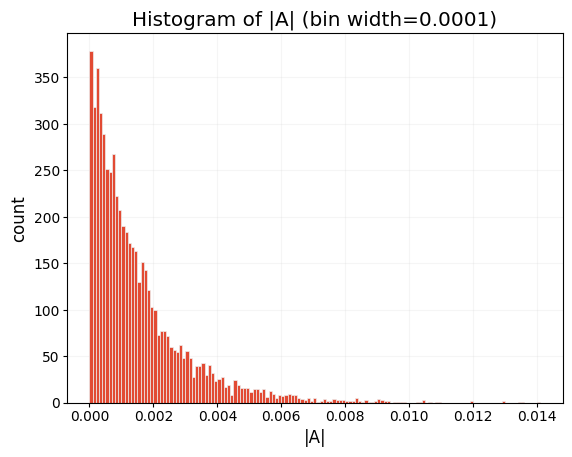

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# A: torch tensor [B,K,Kin] or [B,K,Kin,1]
A_np = A
A_np = np.squeeze(A_np)  # drops trailing 1 if present
vals = np.abs(A_np).ravel()

# fixed-width bins
bin_width = 1e-4  # choose (e.g. 1e-4, 5e-4, 1e-3)
vmax = vals.max()
edges = np.arange(0.0, vmax + bin_width, bin_width)

plt.figure()
plt.hist(vals, bins=edges)
plt.xlabel("|A|")
plt.ylabel("count")
plt.title(f"Histogram of |A| (bin width={bin_width:g})")
plt.show()

tensor([[ 0.6239,  1.6126, -0.1248, -0.0958, -2.0421, -0.3815,  0.9158,  1.2230]],
       grad_fn=<AddmmBackward0>)